In [1]:
import os
import copy
import torch
import warnings
import numpy as np
import pandas as pd
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

from torch_geometric.utils import to_networkx
from torch_geometric.data import Data, DataLoader

import torch.nn.functional as F
from torch.nn import Linear, BatchNorm1d
from torch_geometric.nn import GATv2Conv

from types import SimpleNamespace
warnings.filterwarnings('ignore')

In [2]:
df_features = pd.read_csv('dataset/elliptic_txs_features.csv', header=None)
df_edges = pd.read_csv("dataset/elliptic_txs_edgelist.csv")
df_classes =  pd.read_csv("dataset/elliptic_txs_classes.csv")
df_classes['class'] = df_classes['class'].map({'unknown': 2, '1': 1, '2': 0})

In [5]:
df_classes['class'].value_counts()

class
2    157205
0     42019
1      4545
Name: count, dtype: int64

In [3]:
df_merge = df_features.merge(df_classes, how='left', right_on="txId", left_on=0)
df_merge = df_merge.sort_values(0).reset_index(drop=True)
print(f'df_merge shape {df_merge.shape}')

df_merge shape (203769, 169)


In [5]:
df_merge = df_features.merge(df_classes, how='left', right_on="txId", left_on=0)
df_merge = df_merge.sort_values(0).reset_index(drop=True)
print(f'df_merge shape {df_merge.shape}')

# mapping nodes to indices
nodes = df_merge[0].values
map_id = {j:i for i,j in enumerate(nodes)}

# mapping edges to indices
edges = df_edges.copy()
edges.txId1 = edges.txId1.map(map_id)
edges.txId2 = edges.txId2.map(map_id)
edges = edges.astype(int)
edge_index = np.array(edges.values).T
edge_index = torch.tensor(edge_index, dtype=torch.long).contiguous()

# weights for the edges are equal in case of model without attention
weights = torch.tensor([1] * edge_index.shape[1] , dtype=torch.float32)

# maping node ids to corresponding indexes
node_features = df_merge.drop(['txId'], axis=1).copy()
node_features[0] = node_features[0].map(map_id)

# store known and unknown nodes
classified_idx = node_features['class'].loc[node_features['class'] != 2].index
unclassified_idx = node_features['class'].loc[node_features['class'] == 2].index

# replace unkown class with 0, to avoid having 3 classes, this data/labels never used in training
# node_features['class'] = node_features['class'].replace(2, 0)

labels = node_features['class'].values
y_train = labels[classified_idx]

print(f'node_features {node_features.shape}')
# drop indeces, class and temporal axes
node_features = torch.tensor(np.array(node_features.drop([0, 'class', 1], axis=1).values, dtype=np.float32), dtype=torch.float32)

print(f'node_features {node_features.shape}')

df_merge shape (203769, 169)
node_features (203769, 168)
node_features torch.Size([203769, 165])


In [5]:

print(classified_idx)

Index([     1,      2,      7,      8,     11,     12,     17,     18,     22,
           23,
       ...
       203678, 203679, 203681, 203698, 203699, 203700, 203709, 203727, 203743,
       203750],
      dtype='int64', length=46564)


In [9]:
elliptic_dataset = Data(x = node_features,
                        edge_index = edge_index,
                        edge_attr = weights,
                        y = torch.tensor(labels, dtype=torch.float32))

In [7]:
config = SimpleNamespace(seed = 0,
                         learning_rate = 0.001,
                         weight_decay = 1e-5,
                         input_dim = 165,
                         output_dim = 1,
                         hidden_size = 128,
                         num_epochs = 400,
                         checkpoints_dir = './models/elliptic_gnn',
                         device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

In [10]:
_, _, _, _, train_idx, valid_idx = train_test_split(node_features[classified_idx],
                                                    y_train,
                                                    classified_idx,
                                                    test_size=0.15,
                                                    random_state=config.seed,
                                                    stratify=y_train)

elliptic_dataset.train_idx = torch.tensor(train_idx, dtype=torch.long)
elliptic_dataset.val_idx = torch.tensor(valid_idx, dtype=torch.long)

In [11]:
print(train_idx)

Index([ 76156, 160314,  34236, 108847,  41866, 104566, 118213,  48408, 164924,
         9437,
       ...
        40049,  25310, 135694,  59772, 196772,  23877, 123684, 183698, 101395,
       139016],
      dtype='int64', length=39579)


In [7]:
torch.save(elliptic_dataset, 'graph_data.pt')

In [14]:
class GAT(torch.nn.Module):
    """Graph Attention Network"""
    def __init__(self, dim_in, dim_h, dim_out, heads=8):
        super(GAT, self).__init__()
        self.norm1 = BatchNorm1d(dim_in)
        self.gat1 = GATv2Conv(dim_in, dim_h, heads=heads,
                              dropout=0.3)
        self.norm2 = BatchNorm1d(dim_h*heads)
        self.gat2 = GATv2Conv(dim_h*heads, dim_out, heads=heads,
                              concat=False, dropout=0.6)
        
    def forward(self, x, edge_index):
        h = self.norm1(x)
        h = self.gat1(h, edge_index)
        h = self.norm2(h)
        h = F.leaky_relu(h)
        out = self.gat2(h, edge_index)
        return out


def accuracy(y_pred, y_test, prediction_threshold=0.5):
    y_pred_label = (torch.sigmoid(y_pred) > prediction_threshold).float()

    correct_results_sum = (y_pred_label == y_test).sum().float()
    acc = correct_results_sum/y_test.shape[0]

    return acc

def test(model, data):
    model.eval()
    out = model(data.x, data.edge_index)
    preds = ((torch.sigmoid(out) > 0.5).float()*1).squeeze(1)
    return preds


def train_evaluate(model, data, criterion, optimizer, *args):
    num_epochs = args[0]
    checkpoints_dir = args[1]
    model_filename = args[2]

    best_model_wts = copy.deepcopy(model.state_dict())

    best_loss = float('inf')

    if not os.path.exists(checkpoints_dir):
        os.makedirs(checkpoints_dir)

    model.train()
    for epoch in range(num_epochs+1):
        # Training
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[train_idx], data.y[train_idx].unsqueeze(1))
        acc = accuracy(out[train_idx], data.y[train_idx].unsqueeze(1), prediction_threshold=0.5)
        loss.backward()
        optimizer.step()
        # Validation
        val_loss = criterion(out[valid_idx], data.y[valid_idx].unsqueeze(1))
        val_acc = accuracy(out[valid_idx], data.y[valid_idx].unsqueeze(1), prediction_threshold=0.5)

        if epoch % 10 == 0:
            print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: '
                  f'{acc*100:>6.2f}% | Val Loss: {val_loss:.4f} | '
                  f'Val Acc: {val_acc*100:.2f}%')

            # if val_loss < best_loss:
            #     best_loss = val_loss
            #     print("Saving model for best loss")
            #     checkpoint = {'state_dict': best_model_wts}
            #     torch.save(checkpoint, os.path.join(checkpoints_dir, model_filename))
            #     best_model_wts = copy.deepcopy(model.state_dict())

    return model


In [15]:
torch.manual_seed(config.seed)

gat_model = GAT(config.input_dim, config.hidden_size, config.output_dim).to(config.device)
data_train = elliptic_dataset.to(config.device)

optimizer = torch.optim.Adam(gat_model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
criterion = torch.nn.BCEWithLogitsLoss()

train_evaluate(gat_model,
               data_train,
               criterion,
               optimizer,
               config.num_epochs,
               config.checkpoints_dir,
               'gat_best_model.pth.tar')

Epoch   0 | Train Loss: 0.781 | Train Acc:  49.93% | Val Loss: 0.7867 | Val Acc: 49.23%
Epoch  10 | Train Loss: 0.246 | Train Acc:  90.44% | Val Loss: 0.2474 | Val Acc: 90.41%
Epoch  20 | Train Loss: 0.224 | Train Acc:  91.40% | Val Loss: 0.2222 | Val Acc: 91.60%
Epoch  30 | Train Loss: 0.203 | Train Acc:  92.76% | Val Loss: 0.2051 | Val Acc: 92.74%
Epoch  40 | Train Loss: 0.187 | Train Acc:  93.64% | Val Loss: 0.1897 | Val Acc: 93.54%
Epoch  50 | Train Loss: 0.173 | Train Acc:  94.30% | Val Loss: 0.1712 | Val Acc: 94.35%
Epoch  60 | Train Loss: 0.162 | Train Acc:  94.85% | Val Loss: 0.1623 | Val Acc: 94.69%
Epoch  70 | Train Loss: 0.152 | Train Acc:  95.36% | Val Loss: 0.1593 | Val Acc: 95.03%
Epoch  80 | Train Loss: 0.146 | Train Acc:  95.61% | Val Loss: 0.1490 | Val Acc: 95.49%
Epoch  90 | Train Loss: 0.140 | Train Acc:  95.90% | Val Loss: 0.1420 | Val Acc: 95.78%
Epoch 100 | Train Loss: 0.134 | Train Acc:  96.07% | Val Loss: 0.1373 | Val Acc: 96.08%
Epoch 110 | Train Loss: 0.131 | 

GAT(
  (norm1): BatchNorm1d(165, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gat1): GATv2Conv(165, 128, heads=8)
  (norm2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gat2): GATv2Conv(1024, 1, heads=8)
)

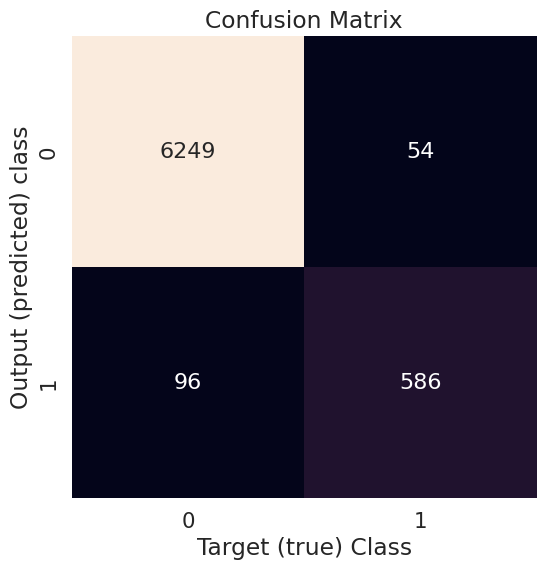

              precision    recall  f1-score   support

       licit     0.9849    0.9914    0.9881      6303
     illicit     0.9156    0.8592    0.8865       682

    accuracy                         0.9785      6985
   macro avg     0.9502    0.9253    0.9373      6985
weighted avg     0.9781    0.9785    0.9782      6985



In [23]:
# gat_model.load_state_dict(torch.load(os.path.join(config.checkpoints_dir, 'gat_best_model.pth.tar'))['state_dict'])

y_test_preds = test(gat_model, data_train)

# confusion matrix on validation data
conf_mat = confusion_matrix(data_train.y[valid_idx].detach().cpu().numpy(), y_test_preds[valid_idx].cpu())

plt.subplots(figsize=(6,6))
sns.set(font_scale=1.4)
sns.heatmap(conf_mat, annot=True, fmt=".0f", annot_kws={"size": 16}, cbar=False)
plt.xlabel('Target (true) Class'); plt.ylabel('Output (predicted) class'); plt.title('Confusion Matrix')
plt.show();

print(classification_report(data_train.y[valid_idx].detach().cpu().numpy(),
                            y_test_preds[valid_idx].cpu(),
                            target_names=['licit', 'illicit'],
                           digits=4))

In [24]:
torch.save(gat_model.state_dict(), 'gat_model.pth')